# HW 1
## Jenn Kaphammer, APPM-5370 9/9/2026

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Q4c

t_peak =  4.0236 ms
I0_crit = 7.4767
\Amplitude results
-------------------------------------------------------
Case                 I0     t_peak (ms)     u_peak (mV)
-------------------------------------------------------
below            6.7291          4.0304          0.8998
at               7.4767          4.0304          0.9998
above            8.2244          4.0304          1.0998


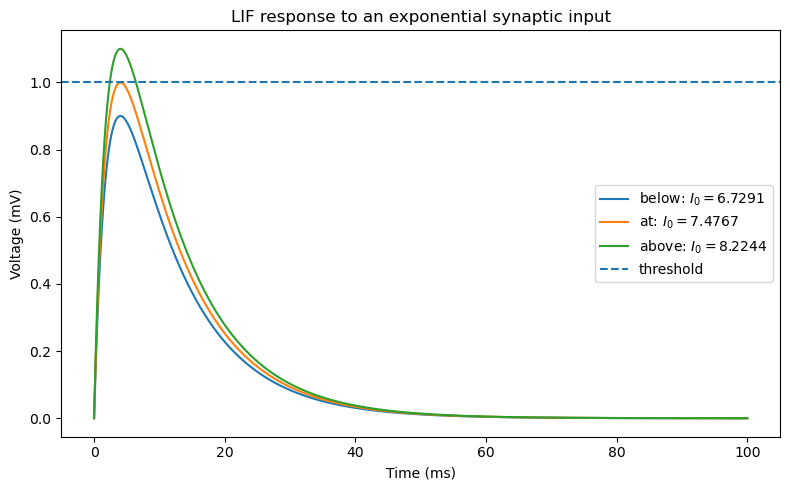

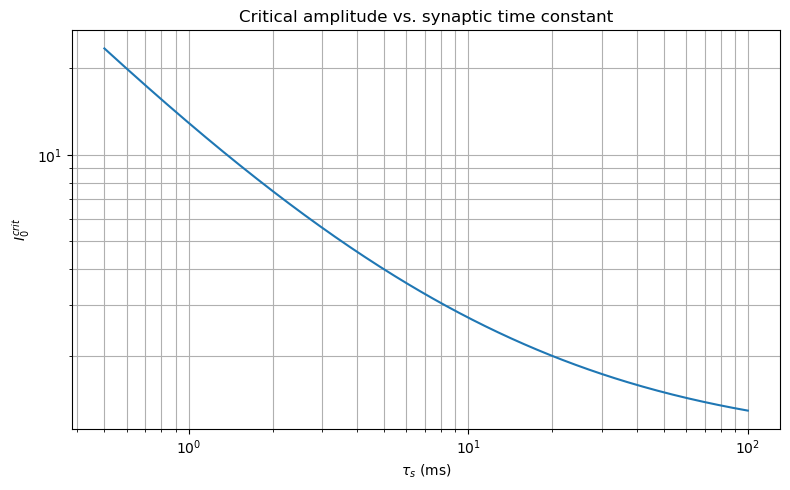

In [11]:
R = 1.0 #ohm
tau_m = 10.0 #ms
tau_s = 2.0 #ms
u_rest = 0.0 #mV
u_th = 1.0 # mV

r = tau_s/tau_m
#part b formula
t_peak_formula = (tau_m*tau_s/(tau_s-tau_m)*np.log(tau_s/tau_m))

Icrit = ((u_th - u_rest)/R*r**(1/(r-1)))
print("t_peak = ", round(t_peak_formula, 4), "ms")
print("I0_crit =", round(Icrit, 4))

def lif_rhs(t, u, I0, tau_s):
    return (-u[0]+R*I0*np.exp(-t/tau_s))/tau_m
#call above lif equation
def solve_lif(I0):
    t = np.linspace(0, 100, 10000)
    sol = solve_ivp(
        lif_rhs,
        [0, 100],
        [0],
        t_eval=t,
        args=(I0, tau_s)
    )
    return sol.t, sol.y[0]
#amplitudes 
amplitudes = {
    "below": 0.9000 * Icrit,
    "at": Icrit,
    "above": 1.1000 * Icrit
}

results = []

for label, I0 in amplitudes.items():
    t, u = solve_lif(I0)
    # peak from ODE
    peak_index = np.argmax(u)
    t_peak_num = t[peak_index]
    u_peak_num = u[peak_index]

    results.append((label, I0, t_peak_num, u_peak_num))

# table
print("\Amplitude results")
print("-" * 55)
print(f"{'Case':<10} {'I0':>12} {'t_peak (ms)':>15} {'u_peak (mV)':>15}")
print("-" * 55)
for label, I0, tpk, upk in results:
    print(f"{label:<10} {I0:12.4f} {tpk:15.4f} {upk:15.4f}")

#plot u(t) above/at/below Icrit
plt.figure(figsize=(8, 5))

for label, I0 in amplitudes.items():
    t, u = solve_lif(I0)
    plt.plot(t, u, label=fr"{label}: $I_0={I0:.4f}$")

plt.axhline(u_th, linestyle="--", label="threshold")

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("LIF response to an exponential synaptic input")
plt.legend()
plt.tight_layout()
plt.show()

#crit amplitude [0.5,100]ms
tau_s_values = np.logspace(np.log10(0.5), np.log10(100), 300)

Icrit_values = []

for ts in tau_s_values:
    r = ts / tau_m
    # formula from part (b)
    if np.isclose(r, 1.0):
        factor = np.e
    else:
        factor = r**(1/(r-1))
    Icrit_ts = (u_th-u_rest)/R*factor
    Icrit_values.append(Icrit_ts)

Icrit_values = np.array(Icrit_values)

plt.figure(figsize=(8, 5))
plt.loglog(tau_s_values, Icrit_values)
plt.xlabel(r"$\tau_s$ (ms)")
plt.ylabel(r"$I_0^{crit}$")
plt.title(r"Critical amplitude vs. synaptic time constant")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

## Q5a

Python port of hh_sim.m. Same parameters, same shifted potential
convention of the 1952 papers, so rest is near V = 0 and the spike peak
near V = 100.

Call it and capture what you need:

    t, V, spk, rate = hh_sim()

Running the file directly (python hh_sim.py) prints the spike count and
rate at the default Id = 7. There is no MATLAB-style ans here, but t is
30001 elements of 0 to 300 in steps of 0.01, so avoid echoing the whole
return value in a notebook cell.

Regression checks with default parameters:
    Id = 7 gives sustained firing at 58.3 Hz
    Id = 5 gives no sustained firing
The 58.3 is solver independent: BDF, LSODA, Radau and RK45 all agree to
three digits, so a port that lands more than a Hz away has a real bug,
most likely a sign in an exponent. The removable singularities in
alpha_m and alpha_n at V = 25 and V = 10 are patched below; if you
rewrite them, check that alpha_m(25) and alpha_n(10) come out finite.

The reported rheobase depends on how you define repetitive firing: both
skipfrac and the spike count you demand of it will move the answer,
because the underlying bifurcation is subcritical. State the criterion
you used rather than treating the number as absolute.

In [12]:
__all__ = ["hh_sim"]


# ---- gating rate functions (ms^-1), with removable singularities patched ----
def _am(V):
    return 1.0 if abs(V - 25) < 1e-6 else 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)


def _bm(V):
    return 4 * np.exp(-V / 18)


def _ah(V):
    return 0.07 * np.exp(-V / 20)


def _bh(V):
    return 1 / (np.exp((30 - V) / 10) + 1)


def _an(V):
    return 0.1 if abs(V - 10) < 1e-6 else 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)


def _bn(V):
    return 0.125 * np.exp(-V / 80)


def hh_sim(Id=7.0, tmax=300.0, gK=36.0, gNa=120.0, skipfrac=0.4):
    """Integrate the HH model under constant current.

    Parameters
    ----------
    Id : injected current density (uA/cm^2). Defaults to 7, above
         rheobase, so hh_sim() with no arguments gives repetitive
         firing.
    tmax : simulation duration (ms).
    gK, gNa : maximal conductances (mS/cm^2).
    skipfrac : fraction of the trace discarded before counting spikes, so
        that the onset transient is not mistaken for repetitive firing.

    Returns
    -------
    t, V : time vector (ms) and voltage trace (mV).
    spk : spike times, upward crossings of 40 mV.
    rate : mean firing rate in Hz over the counted window, 0 if fewer
        than two spikes.
    """
    C, gL, ENa, EK, EL = 1.0, 0.3, 115.0, -12.0, 10.6

    def rhs(_, y):
        V, m, h, n = y
        INa = gNa * m**3 * h * (V - ENa)
        IK = gK * n**4 * (V - EK)
        IL = gL * (V - EL)
        return [
            (Id - INa - IK - IL) / C,
            _am(V) * (1 - m) - _bm(V) * m,
            _ah(V) * (1 - h) - _bh(V) * h,
            _an(V) * (1 - n) - _bn(V) * n,
        ]

    V0 = 0.0  # steady state gating at rest
    y0 = [
        V0,
        _am(V0) / (_am(V0) + _bm(V0)),
        _ah(V0) / (_ah(V0) + _bh(V0)),
        _an(V0) / (_an(V0) + _bn(V0)),
    ]

    t = np.arange(0, tmax + 1e-9, 0.01)
    sol = solve_ivp(rhs, [0, tmax], y0, method="BDF", t_eval=t,
                    rtol=1e-8, atol=1e-10, max_step=0.05)
    V = sol.y[0]

    i0 = max(1, int(round(skipfrac * len(t))))
    up = np.flatnonzero((V[i0:-1] < 40) & (V[i0 + 1:] >= 40)) + i0
    spk = t[up]

    rate = 1000 * (len(spk) - 1) / (spk[-1] - spk[0]) if len(spk) >= 2 else 0.0
    return t, V, spk, rate

In [13]:
if __name__ == "__main__":
    t, V, spk, rate = hh_sim()
    print(f"Id = 7: {len(spk)} spikes, rate = {rate:.1f} Hz")

Id = 7: 11 spikes, rate = 58.3 Hz


I chose the criterion of 40% skipfrac and a spike count of 2 (based on provided code default).

In [14]:
# 5 < r < 7 chosen on given info of "Regression checks with default parameters: Id = 7 gives sustained firing at 58.3 Hz Id = 5 gives no sustained firing"
smallest = 5.0
largest = 7.0
inv = 0.001 # 3 decimal places

while (largest-smallest)>inv:
    avg = (smallest+largest)/2
    #call hh
    t, V, spk, rate = hh_sim(Id=avg)
    # at least 2 spike criterion
    if len(spk) >= 2:
        largest = avg
    else:
        smallest = avg
#take largest saved num        
rheobase = largest
print("rheobase = ", round(rheobase, 3))

rheobase =  6.257


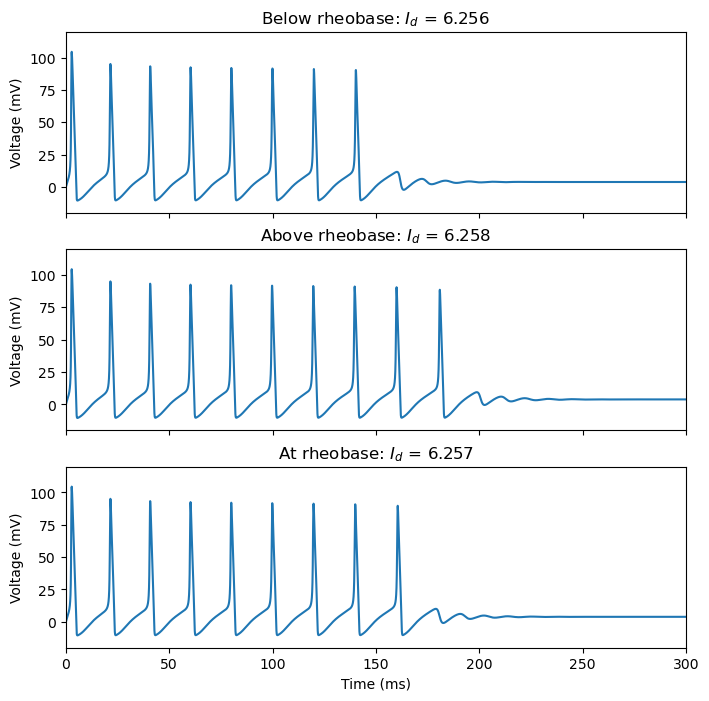

In [15]:
#run sims
t1, V1, spk1, rate1 = hh_sim(Id=6.256) 
t2, V2, spk2, rate2 = hh_sim(Id=6.258) 
t3, V3, spk3, rate3 = hh_sim(Id=6.257)

fig, ax = plt.subplots(3, 1, figsize=(8, 8),
                       sharex=True, sharey=True)
# below r
ax[0].plot(t1, V1)
ax[0].set_title("Below rheobase: $I_d$ = 6.256")
ax[0].set_ylabel("Voltage (mV)")

# above r
ax[1].plot(t2, V2)
ax[1].set_title("Above rheobase: $I_d$ = 6.258")
ax[1].set_ylabel("Voltage (mV)")
# At r
ax[2].plot(t3, V3)
ax[2].set_title("At rheobase: $I_d$ = 6.257")
ax[2].set_xlabel("Time (ms)")
ax[2].set_ylabel("Voltage (mV)")

# plot limits
ax[0].set_xlim(0, 300)
ax[0].set_ylim(-20, 120)

plt.show()

In [17]:
# print(I_below, len(spk1), rate1)
# print(I_above, len(spk2), rate2)

## Q5b 

In [19]:
#make steps up to ~twice rheobase
currents = np.arange(6.257, 12.500, 0.25)
rates = []
for Id in currents:
    t, V, spk, rate = hh_sim(Id=Id)
    rates.append(rate)

    print("Id = ", round(Id, 3), " , rate = ", round(rate, 3))

Id =  6.257  , rate =  48.614
Id =  6.507  , rate =  55.083
Id =  6.757  , rate =  56.933
Id =  7.007  , rate =  58.343
Id =  7.257  , rate =  59.54
Id =  7.507  , rate =  60.606
Id =  7.757  , rate =  61.576
Id =  8.007  , rate =  62.48
Id =  8.257  , rate =  63.331
Id =  8.507  , rate =  64.136
Id =  8.757  , rate =  64.904
Id =  9.007  , rate =  65.64
Id =  9.257  , rate =  66.345
Id =  9.507  , rate =  67.028
Id =  9.757  , rate =  67.69
Id =  10.007  , rate =  68.331
Id =  10.257  , rate =  68.953
Id =  10.507  , rate =  69.563
Id =  10.757  , rate =  70.153
Id =  11.007  , rate =  70.734
Id =  11.257  , rate =  71.301
Id =  11.507  , rate =  71.852
Id =  11.757  , rate =  72.394
Id =  12.007  , rate =  72.926
Id =  12.257  , rate =  73.448


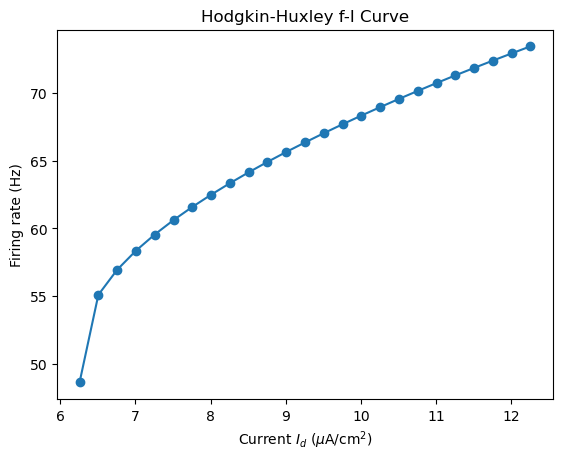

In [20]:
plt.plot(currents, rates, 'o-')
plt.xlabel("Current $I_d$ ($\mu$A/cm$^2$)")
plt.ylabel("Firing rate (Hz)")
plt.title("Hodgkin-Huxley f-I Curve")
plt.show()

## Q5c

In [21]:
#find boundaries for gK=30 rheobase
for Id in [0, 1, 2, 3, 4, 5]:
    t, V, spk, rate = hh_sim(Id=Id, gK=30.0)
    print(Id, len(spk), rate)

0 0 0.0
1 0 0.0
2 0 0.0
3 9 49.89397530248223
4 10 56.63583160279403
5 11 60.8976310821509


In [22]:
# 2 < r <= 3 based on above calculation
smallest = 2.0
largest = 3.0
inv = 0.001 # 3 decimal places

while (largest-smallest)>inv:
    avg = (smallest+largest)/2
    #call hh
    t, V, spk, rate = hh_sim(Id=avg,gK=30.0)
    # at least 2 spike criterion
    if len(spk) >= 2:
        largest = avg
    else:
        smallest = avg
#take largest saved num        
rheobase = largest
print("rheobase = ", round(rheobase, 3))

rheobase =  2.773


In [23]:
#make steps up to ~twice rheobase
currents_new_gK = np.arange(2.773, 6.000, 0.25)
rates_new_gK = []
for Id in currents_new_gK:
    t, V, spk, rate = hh_sim(Id=Id,gK=30.0)
    rates_new_gK.append(rate)

    print("Id = ", round(Id, 3), " , rate = ", round(rate, 3))

Id =  2.773  , rate =  40.469
Id =  3.023  , rate =  50.147
Id =  3.273  , rate =  52.346
Id =  3.523  , rate =  54.031
Id =  3.773  , rate =  55.467
Id =  4.023  , rate =  56.747
Id =  4.273  , rate =  57.917
Id =  4.523  , rate =  59.001
Id =  4.773  , rate =  60.024
Id =  5.023  , rate =  60.987
Id =  5.273  , rate =  61.904
Id =  5.523  , rate =  62.786
Id =  5.773  , rate =  63.629


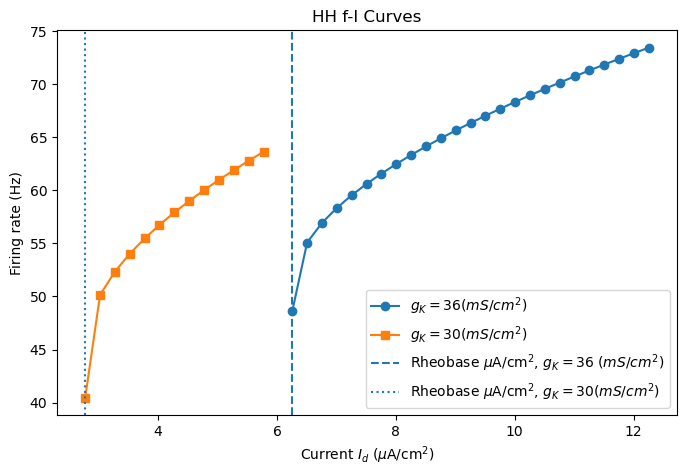

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(currents, rates, 'o-', label="$g_K = 36$$(mS/cm^2)$")
plt.plot(currents_new_gK, rates_new_gK, 's-', label="$g_K = 30$$(mS/cm^2)$")
plt.axvline(6.257, linestyle='--',
            label=("Rheobase $\mu\mathrm{A}/\mathrm{cm}^2$, $g_K=36$ $(mS/cm^2)$"))

plt.axvline(2.773, linestyle=':',
            label=("Rheobase $\mu\mathrm{A}/\mathrm{cm}^2$, $g_K=30$$(mS/cm^2)$"))
plt.xlabel("Current $I_d$ ($\mu$A/cm$^2$)")
plt.ylabel("Firing rate (Hz)")
plt.title("HH f-I Curves")
plt.legend()

plt.show()